Shape of combined data: (143754, 29)
name of columns loaded from file: 10 11 1


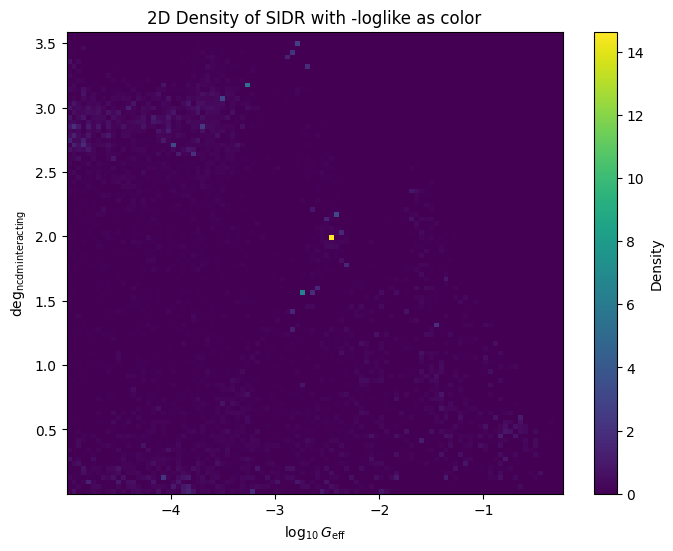

In [4]:
#This is for the 1mio chains that work

import numpy as np
import matplotlib.pyplot as plt
folder = "/home/jeppethybo/connect_public/Grendel_files/SIDR_interacting_and_std"
files = [
    "2026-02-27_200000__0.txt",
    "2026-02-27_200000__1.txt",
    "2026-02-27_200000__2.txt",
    "2026-02-27_200000__3.txt",
    "2026-02-27_200000__4.txt",
    "2026-02-27_200000__5.txt",
]

combined_files = [folder + '/' + f for f in files] 
chains = [np.loadtxt(f) for f in combined_files]
chains = [c[int(0.3 * len(c)):] for c in chains]  # Discard first 30% as burn-in
data = np.vstack(chains)  # Combine all chains into one array

print("Shape of combined data:", data.shape)

logG_col = 10
deg_col = 11
negloglike_col = 1

print("name of columns loaded from file:", logG_col, deg_col, negloglike_col)
x = data[:, logG_col]
y = data[:, deg_col]
z = data[:, negloglike_col]

plt.figure(figsize=(8,6))
plt.hist2d(x, y, bins=100, density=True, cmap='viridis')

plt.xlabel(r'$\log_{10} G_{\rm eff}$')
plt.ylabel(r'deg$_{\rm ncdm interacting}$')
plt.colorbar(label='Density')
plt.title('2D Density of SIDR with -loglike as color')
plt.show()

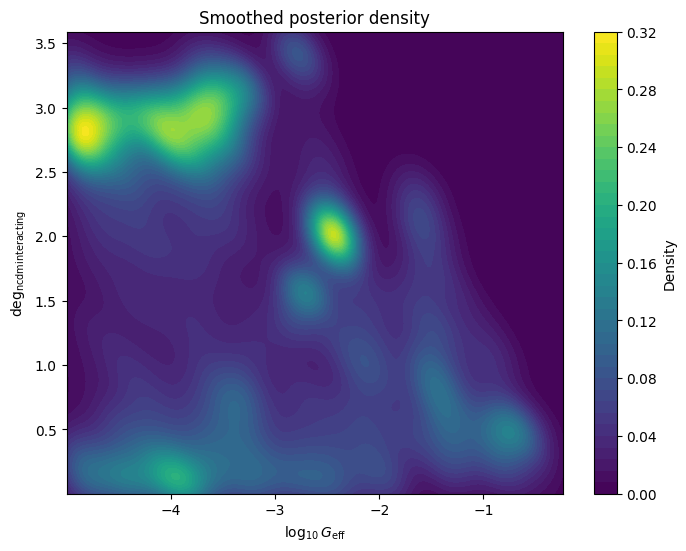

In [3]:
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt
folder = "/home/jeppethybo/connect_public/Grendel_files/SIDR_interacting_and_std"
files = [
    "2026-02-27_200000__0.txt",
    "2026-02-27_200000__1.txt",
    "2026-02-27_200000__2.txt",
    "2026-02-27_200000__3.txt",
    "2026-02-27_200000__4.txt",
    "2026-02-27_200000__5.txt",
]

combined_files = [folder + '/' + f for f in files] 
chains = [np.loadtxt(f) for f in combined_files]
chains = [c[int(0.3 * len(c)):] for c in chains]  # Discard first 30% as burn-in
data = np.vstack(chains)  # Combine all chains into one array

logG_col = 10
deg_col = 11
negloglike_col = 1
x = data[:, logG_col]
y = data[:, deg_col]
z = data[:, negloglike_col]


xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# high-resolution grid
xi, yi = np.mgrid[x.min():x.max():300j, y.min():y.max():300j]
zi = kde(np.vstack([xi.flatten(), yi.flatten()]))

plt.figure(figsize=(8,6))

plt.contourf(xi, yi, zi.reshape(xi.shape), levels=50, cmap='viridis')
plt.colorbar(label='Density')

plt.xlabel(r'$\log_{10} G_{\rm eff}$')
plt.ylabel(r'deg$_{\rm ncdm interacting}$')
plt.title('Smoothed posterior density')

plt.show()